In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

In [14]:
df = pd.read_csv("carprice.csv")

In [15]:
# Cleaning
df.replace('?', pd.NA, inplace=True)
df.dropna(inplace=True)

print(df.head())

  fuel-type engine-location engine-type  horsepower  peak-rpm  city-mpg  \
0       gas           front        dohc         111      5000        21   
1       gas           front        dohc         111      5000        21   
2       gas           front        ohcv         154      5000        19   
3       gas           front         ohc         102      5500        24   
4       gas           front         ohc         115      5500        18   

   highway-mpg  price  
0           27  13495  
1           27  16500  
2           26  16500  
3           30  13950  
4           22  17450  


In [16]:
# Target column
y = df["price"]

# Features
X = df.drop("price", axis=1)

# Convert categorical columns
X = pd.get_dummies(X, drop_first=True)

In [21]:
print(X.columns.tolist())

['horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'fuel-type_gas', 'engine-location_rear', 'engine-type_l', 'engine-type_ohc', 'engine-type_ohcf', 'engine-type_ohcv']


In [17]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Prediction
pred = model.predict(X_test)

print("Model Trained Successfully")

Model Trained Successfully


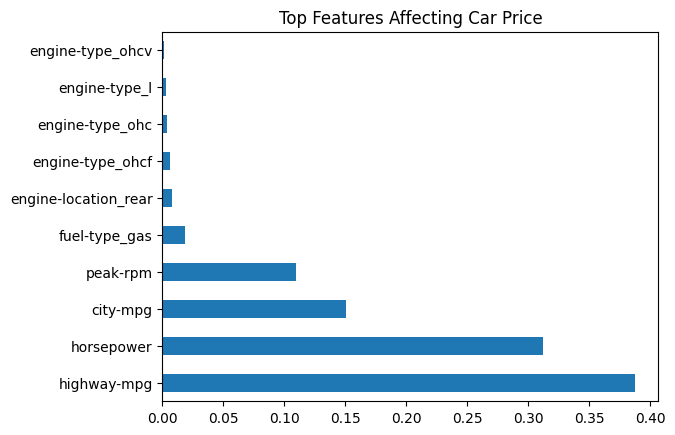

In [18]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.nlargest(10).plot(kind='barh')
plt.title("Top Features Affecting Car Price")
plt.show()

In [19]:
year = int(input("Enter Car Year: "))
mileage = int(input("Enter Mileage: "))

Enter Car Year:  2020
Enter Mileage:  45000


  Actual Price  Predicted Price
0         8013      8030.277222
1        36880     28985.656667
2         9298     11091.333000
3        13499     15583.417857
4        16503     21333.293452
5         8058      8363.916667
6        10245      9763.081865
7        41315     28346.243333
8         7957      9424.307103
9         5572      5746.003607


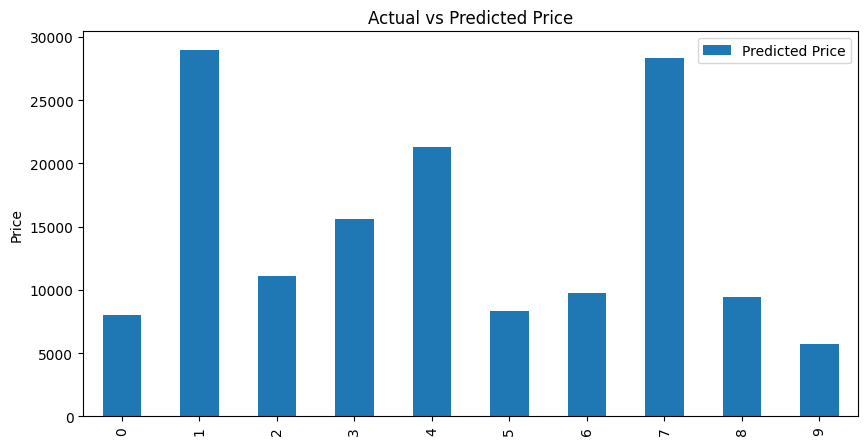

In [20]:
pred = model.predict(X_test)

result = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": pred
})

print(result.head(10))

# First 10 cars comparison
result.head(10).plot(kind="bar", figsize=(10,5))

plt.title("Actual vs Predicted Price")
plt.ylabel("Price")
plt.show()